In [46]:
from api import *
from myutils import *

from datetime import datetime, timedelta, timezone

In [47]:
class EsayDcam(Dcam):
    def __init__(self, iDevice=0):
        super().__init__(iDevice)
        self.EZ_isopen = False


    def __enter__(self):
        Dcamapi.init()
        self.dev_open()
        self.prop_setvalue(DCAM_IDPROP.SENSORCOOLER, DCAMPROP.SENSORCOOLER.MAX)
        self.EZ_isopen = True
        return self


    def __exit__(self, *args):
        if self.EZ_isopen:
            self.cap_stop()
            self.buf_release()
            self.dev_close()
            Dcamapi.uninit()
            self.EZ_isopen = False
            print('exited')


    def EZ_exposure_time(self, exposure_time):
        self.prop_setvalue(DCAM_IDPROP.EXPOSURETIME, exposure_time)


    def EZ_triggersource_masterpluse(self, burst_times, interval):
        self.prop_setvalue(DCAM_IDPROP.TRIGGERSOURCE, DCAMPROP.TRIGGERSOURCE.MASTERPULSE)
        self.prop_setvalue(DCAM_IDPROP.MASTERPULSE_MODE, DCAMPROP.MASTERPULSE_MODE.BURST)
        self.prop_setvalue(DCAM_IDPROP.MASTERPULSE_TRIGGERSOURCE, DCAMPROP.MASTERPULSE_TRIGGERSOURCE.SOFTWARE)

        self.prop_setvalue(DCAM_IDPROP.MASTERPULSE_BURSTTIMES, burst_times)
        self.prop_setvalue(DCAM_IDPROP.MASTERPULSE_INTERVAL, interval)

    
    def EZ_triggersource_external(self):
        self.prop_setvalue(DCAM_IDPROP.TRIGGERSOURCE, DCAMPROP.TRIGGERSOURCE.EXTERNAL)


    def EZ_temperature(self):
        return self.prop_getvalue(DCAM_IDPROP.SENSORTEMPERATURE)
    

    def EZ_roi(self, X0, Y0, W, H):
        self.prop_setvalue(DCAM_IDPROP.SUBARRAYHPOS, X0)
        self.prop_setvalue(DCAM_IDPROP.SUBARRAYVPOS, Y0)
        self.prop_setvalue(DCAM_IDPROP.SUBARRAYHSIZE, W)
        self.prop_setvalue(DCAM_IDPROP.SUBARRAYVSIZE, H)
        self.prop_setvalue(DCAM_IDPROP.SUBARRAYMODE,  2)


    def EZ_wait_capture(self, timeout=18446744073709551616):
        while True:
            if self.wait_event(DCAMWAIT_CAPEVENT.CYCLEEND, timeout) is not False:
                break

    
    def EZ_read_buf(self, iFrame, read_timestamp=True):
        frame = self.buf_getframe(iFrame)
        timestamp = self.EZ_fmt_time(frame[0]) if read_timestamp else 0
        data = frame[1]
        return data, timestamp


    @classmethod
    def EZ_fmt_time(self, buf_frame: DCAMBUF_FRAME):
        total_seconds = buf_frame.timestamp.sec + buf_frame.timestamp.microsec / 1_000_000
        china_time = datetime.fromtimestamp(total_seconds, tz=timezone.utc).astimezone(timezone(timedelta(hours=8)))
        return china_time.strftime('%Y-%m-%d %H:%M:%S.%f') 



In [48]:
class EasyALP4(ALP4):
    def __init__(self, version='4.3', libDir='./api/'):
        super().__init__(version, libDir)
        self.EZ_isopen = False


    def __enter__(self):
        self.Initialize()
        self.EZ_load_seq([self.EZ_single_pixel(0)])
        self.Run(loop=False)
        self.Wait()
        self.EZ_isopen = True
        return self


    def __exit__(self, *args):
        self.Halt()
        try:
            self.FreeSeq()
        except ValueError:
            pass
        self.Free()
        self.EZ_isopen = False
        print('exited')

    
    def EZ_single_pixel(self, pixels):
        img = np.ones([self.nSizeY, self.nSizeX]) * (2**8 - 1)
        img[self.nSizeY//2 - pixels, self.nSizeX//2 + pixels] = 0
        return img.ravel()


    def EZ_load_seq(self, Imgs, PictureTime=50):
        imgSeq = np.concatenate(Imgs)
        self.SeqAlloc(nbImg=len(Imgs), bitDepth=1)
        self.SeqPut(imgData=imgSeq)
        self.SeqControl(ALP_BIN_MODE, ALP_BIN_UNINTERRUPTED)
        self.SetTiming(pictureTime=PictureTime)



In [49]:
SPADE_ROI = {
    'X0': 2128,
    'Y0': 720,

     'W': 180,
     'H': 500
}

In [56]:
with EsayDcam() as dcam:
    with EasyALP4() as alp:
        A = 5
        samples = 50
        repeat = 200

        interval = 50e-3

        exposure_time = 500e-6 #500 us
        picture_time = 10000 // 2 #10000 us

        alp.EZ_load_seq([alp.EZ_single_pixel(0), alp.EZ_single_pixel(A)])

        dcam.EZ_exposure_time(exposure_time)
        dcam.EZ_triggersource_masterpluse(samples, interval)
        dcam.EZ_roi(**SPADE_ROI)

        data, timestamp = [], []
        for _ in tqdm(range(repeat)):
            dcam.buf_alloc(samples)
            dcam.cap_snapshot()

            alp.Run()
            sleep(1e-6)
            dcam.cap_firetrigger()

            dcam.EZ_wait_capture()

            dcam.cap_stop()
            alp.Halt()

            data_, timestamp_ = [], []
            for frame in range(samples):
                framedata_ = dcam.EZ_read_buf(frame)
                data_.append(framedata_[0])
                timestamp_.append(framedata_[1])

            dcam.buf_release()

        data.append(data_)
        timestamp.append(timestamp_)

np.save('./test.npy', np.array(data))
np.save('./timestamp.npy', np.array(timestamp))

Loading library: ./api/x64/alp4395.dll
DMD found, resolution = 1024 x 768.


100%|██████████| 200/200 [09:05<00:00,  2.73s/it]

exited
exited


In [57]:
np.load('timestamp.npy')

array([['2024-10-17 16:46:52.150166', '2024-10-17 16:46:52.200163',
        '2024-10-17 16:46:52.250167', '2024-10-17 16:46:52.300164',
        '2024-10-17 16:46:52.350160', '2024-10-17 16:46:52.400164',
        '2024-10-17 16:46:52.450161', '2024-10-17 16:46:52.500165',
        '2024-10-17 16:46:52.550162', '2024-10-17 16:46:52.600166',
        '2024-10-17 16:46:52.650163', '2024-10-17 16:46:52.700167',
        '2024-10-17 16:46:52.750164', '2024-10-17 16:46:52.800160',
        '2024-10-17 16:46:52.850164', '2024-10-17 16:46:52.900161',
        '2024-10-17 16:46:52.950165', '2024-10-17 16:46:53.000162',
        '2024-10-17 16:46:53.050166', '2024-10-17 16:46:53.100163',
        '2024-10-17 16:46:53.150167', '2024-10-17 16:46:53.200164',
        '2024-10-17 16:46:53.250160', '2024-10-17 16:46:53.300164',
        '2024-10-17 16:46:53.350161', '2024-10-17 16:46:53.400165',
        '2024-10-17 16:46:53.450162', '2024-10-17 16:46:53.500166',
        '2024-10-17 16:46:53.550163', '2024-10-1

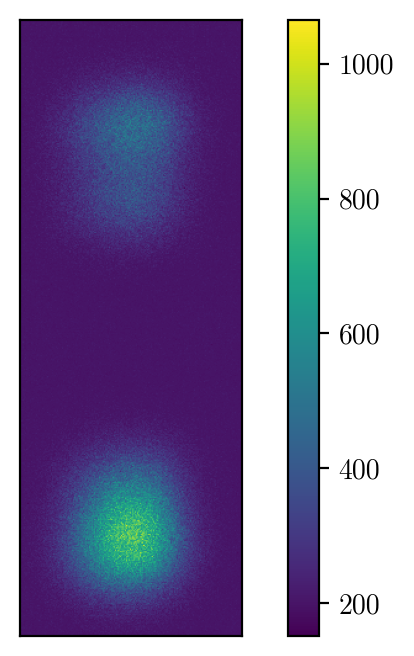

In [59]:
imshow(read('test.npy')[0, 0])

In [60]:
a = read('test.npy')

In [62]:
a.shape

(1, 50, 500, 180)